# Project 2 — Supervised Learning: Fraud Detection Pipeline

**DecodeLabs Data Science — Project 2**

### Objective
Build a supervised-learning classification pipeline for a highly imbalanced transaction dataset, using SMOTE and comparing Logistic Regression with Random Forest.

### Important data note
The supplied e-commerce data contains **no observed fraud label**. Therefore, `IsFraud` in this project is a **synthetically generated educational target** based on transaction-level risk characteristics. Model performance measures recovery of that simulated mechanism and must not be interpreted as real-world fraud-detection performance.

### Dataset provenance
The synthetic Project 2 dataset was prepared **before this modeling notebook** and is consumed here as the fixed input dataset. The dataset is hosted in the project GitHub repository:

**Dataset:** https://github.com/rsf-rawnak/DecodeLabs-DS-Internship/blob/main/Initial-dataset/Synthetic-dataset/project2_fraud_dataset.csv

The notebook reads the CSV directly from the corresponding GitHub raw-file endpoint so that the analysis is reproducible without requiring a local copy.

### Assignment-aligned requirements
- Handle an imbalanced target with SMOTE.
- Train Logistic Regression and Random Forest models.
- Evaluate using Precision, Recall, F1-score and ROC-AUC.
- Do not use Accuracy as the primary evaluation metric.
- Examine classification-threshold tradeoffs.
- Keep the test set untouched by SMOTE.

## 1. Project structure and modeling decisions

The Project 1 cleaned dataset is the upstream data source. The synthetic fraud dataset was generated separately before this notebook, following the documented Project 2 methodology. This notebook begins at the modeling stage and does **not** regenerate or modify the synthetic target.

### Modeling features

`Product`, `Quantity`, `UnitPrice`, `PaymentMethod`, `ItemsInCart`, `CouponCode`, `ReferralSource`, `TotalPrice`, `UsedCoupon`, `OrderMonth`, `OrderYear`

### Target

`IsFraud`

### Excluded columns

- Identifiers: `OrderID`, `CustomerID`, `TrackingNumber`
- High-cardinality/address field: `ShippingAddress`
- Post-transaction outcome: `OrderStatus`
- Redundant/derived fields: `Date`, `PricePerItem`, `CalculatedTotal`, `TotalPriceDifference`

`OrderID` is retained in the source dataset only for traceability and is never supplied to the model.

In [1]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 20260925

# Human-facing dataset page supplied for the project
DATASET_PAGE_URL = "https://github.com/rsf-rawnak/DecodeLabs-DS-Internship/blob/main/Initial-dataset/Synthetic-dataset/project2_fraud_dataset.csv"

# Direct CSV endpoint for reproducible pd.read_csv() access
DATA_URL = "https://raw.githubusercontent.com/rsf-rawnak/DecodeLabs-DS-Internship/main/Initial-dataset/Synthetic-dataset/project2_fraud_dataset.csv"

In [2]:
# Load the fixed Project 2 synthetic dataset directly from GitHub
df = pd.read_csv(DATA_URL)

print("Dataset source:", DATASET_PAGE_URL)
print("Shape:", df.shape)
display(df.head())

Dataset source: https://github.com/rsf-rawnak/DecodeLabs-DS-Internship/blob/main/Initial-dataset/Synthetic-dataset/project2_fraud_dataset.csv
Shape: (1200, 21)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,CouponCode,ReferralSource,TotalPrice,PricePerItem,UsedCoupon,OrderMonth,OrderYear,CalculatedTotal,TotalPriceDifference,IsFraud
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,SAVE10,Instagram,2853.10,570.62,1,1,2023,2853.10,0.000000e+00,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,SAVE10,Referral,302.70,151.35,1,8,2024,302.70,0.000000e+00,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,FREESHIP,Email,2753.40,550.68,1,2,2024,2753.40,4.547474e-13,0
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,SAVE10,Facebook,273.19,273.19,1,10,2023,273.19,0.000000e+00,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,SAVE10,Email,2504.04,626.01,1,5,2025,2504.04,0.000000e+00,0


In [3]:
# Basic validation
required_columns = [
    "OrderID", "Date", "CustomerID", "Product", "Quantity",
    "UnitPrice", "ShippingAddress", "PaymentMethod", "OrderStatus",
    "TrackingNumber", "ItemsInCart", "CouponCode", "ReferralSource",
    "TotalPrice", "PricePerItem", "UsedCoupon", "OrderMonth",
    "OrderYear", "CalculatedTotal", "TotalPriceDifference", "IsFraud"
]
missing_required = [c for c in required_columns if c not in df.columns]
assert not missing_required, f"Missing required columns: {missing_required}"
assert set(df["IsFraud"].dropna().unique()).issubset({0, 1}), "IsFraud must be binary (0/1)."

validation = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Missing values",
        "Duplicate rows",
        "Fraud records",
        "Non-fraud records",
        "Fraud percentage",
        "Non-fraud percentage"
    ],
    "Result": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        int(df["IsFraud"].sum()),
        int((df["IsFraud"] == 0).sum()),
        round(df["IsFraud"].mean() * 100, 2),
        round((1 - df["IsFraud"].mean()) * 100, 2)
    ]
})

display(validation)

print("Target distribution:")
display(df["IsFraud"].value_counts().rename_axis("IsFraud").to_frame("Count"))

print("Data types:")
display(df.dtypes.to_frame("dtype"))

,Check,Result
0,Rows,1200.0
1,Columns,21.0
2,Missing values,0.0
3,Duplicate rows,0.0
4,Fraud records,102.0
5,Non-fraud records,1098.0
6,Fraud percentage,8.5
7,Non-fraud percentage,91.5


Target distribution:


,Count
IsFraud,
0,1098
1,102


Data types:


,dtype
OrderID,object
Date,object
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object


## 2. Synthetic fraud-label disclosure

The Project 2 dataset was generated **before this modeling notebook** because the supplied e-commerce data contained no observed fraud label. The resulting `project2_fraud_dataset.csv` is therefore treated as the fixed modeling input.

The synthetic label-generation methodology documented for this project uses a reproducible probabilistic mechanism involving:

- transaction-value percentile
- unit-price percentile
- quantity
- cart size
- online payment flag
- coupon usage
- Facebook referral
- selected product categories

The documented mechanism combines these factors into a latent risk score, converts that score to a probability, and generates `IsFraud` with a reproducible Bernoulli draw. The temporary `risk_score` and `fraud_probability` used during dataset creation are **not present in the final modeling dataset**.

> **Important:** This notebook intentionally does not regenerate the synthetic label because the synthetic dataset was prepared as a separate project input before modeling.

> **Limitation:** The model is learning a synthetic educational fraud mechanism, not verified real-world fraud behavior.

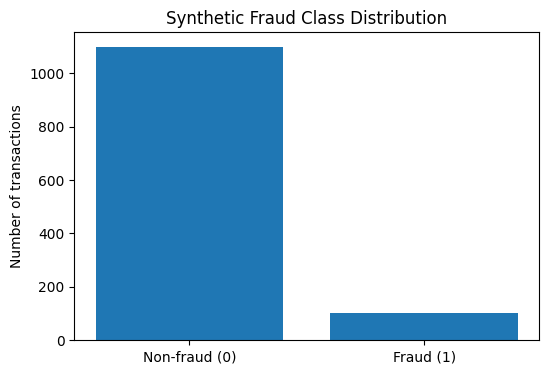

Imbalance ratio (non-fraud : fraud): 10.76:1


In [4]:
# Visualize class imbalance
class_counts = df["IsFraud"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.ylabel("Number of transactions")
plt.title("Synthetic Fraud Class Distribution")
plt.show()

print(f"Imbalance ratio (non-fraud : fraud): "
      f"{class_counts.get(0, 0) / max(class_counts.get(1, 0), 1):.2f}:1")

## 3. Feature selection and leakage audit

The following variables are deliberately excluded because they are identifiers, post-transaction information, redundant derived fields, or cleaning artifacts.

In particular, `OrderStatus` is **not** treated as a fraud label and is not used as a predictor.

In [5]:
TARGET = "IsFraud"

FEATURES = [
    "Product",
    "Quantity",
    "UnitPrice",
    "PaymentMethod",
    "ItemsInCart",
    "CouponCode",
    "ReferralSource",
    "TotalPrice",
    "UsedCoupon",
    "OrderMonth",
    "OrderYear"
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Features:")
print(FEATURES)
print("\nTarget:", TARGET)

assert TARGET not in FEATURES
assert "OrderStatus" not in FEATURES
assert "OrderID" not in FEATURES
assert "risk_score" not in X.columns
assert "fraud_probability" not in X.columns

print("\nLeakage checks passed.")

Features:
['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'UsedCoupon', 'OrderMonth', 'OrderYear']

Target: IsFraud

Leakage checks passed.


In [6]:
# Train/test split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=False).rename_axis("IsFraud").to_frame("Count"))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=False).rename_axis("IsFraud").to_frame("Count"))

Training rows: 960
Test rows: 240

Training target distribution:


,Count
IsFraud,
0,878
1,82



Test target distribution:


,Count
IsFraud,
0,220
1,20


## 4. Preprocessing

Categorical variables are one-hot encoded.

Numeric variables are imputed and standardized for Logistic Regression.

SMOTE is applied **inside the training pipeline only**, after preprocessing and after the train/test split.

The test set is never oversampled.

In [7]:
categorical_features = [
    "Product",
    "PaymentMethod",
    "CouponCode",
    "ReferralSource"
]

numeric_features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "UsedCoupon",
    "OrderMonth",
    "OrderYear"
]

numeric_transformer = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'UsedCoupon', 'OrderMonth', 'OrderYear']
Categorical features: ['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource']


## 5. Logistic Regression with SMOTE

Logistic Regression provides an interpretable linear baseline for the synthetic fraud classification problem.

In [8]:
logistic_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight=None,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]

lr_metrics = {
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, lr_pred, zero_division=0),
    "Recall": recall_score(y_test, lr_pred, zero_division=0),
    "F1": f1_score(y_test, lr_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, lr_prob)
}

pd.DataFrame([lr_metrics])

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.10989,0.5,0.18018,0.580682


## 6. Random Forest with SMOTE

Random Forest is included as the second required classification algorithm and can capture nonlinear interactions among the transaction features.

In [9]:
rf_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    "Model": "Random Forest",
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1": f1_score(y_test, rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

pd.DataFrame([rf_metrics])

,Model,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.0,0.0,0.0,0.589318


## 7. Model comparison

The primary evaluation metrics are Precision, Recall, F1-score and ROC-AUC.

Accuracy is deliberately not used as the primary metric because the non-fraud class is much larger than the fraud class.

The comparison should be interpreted together with the threshold analysis below. ROC-AUC summarizes ranking performance across thresholds, whereas Precision, Recall and F1 at a specific threshold describe the classifier's operational behavior at that threshold.

In [10]:
results = pd.DataFrame([lr_metrics, rf_metrics]).set_index("Model")
display(results.round(4))

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.1099,0.5,0.1802,0.5807
Random Forest,0.0000,0.0,0.0000,0.5893


In [11]:
# Default-threshold interpretation
for name, y_pred, probabilities in [
    ("Logistic Regression", lr_pred, lr_prob),
    ("Random Forest", rf_pred, rf_prob)
]:
    print(f"{name}:")
    print(f"  Positive predictions at threshold 0.50: {int(y_pred.sum())}")
    print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"  F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, probabilities):.4f}")
    print()

print("Interpretation: ROC-AUC evaluates ranking across thresholds, while Precision/Recall/F1 at 0.50 describe behavior at one operating point. Therefore, a model can have non-zero ROC-AUC while producing few or no positive predictions at the default threshold.")

Logistic Regression:
  Positive predictions at threshold 0.50: 91
  Precision: 0.1099
  Recall:    0.5000
  F1:        0.1802
  ROC-AUC:   0.5807

Random Forest:
  Positive predictions at threshold 0.50: 0
  Precision: 0.0000
  Recall:    0.0000
  F1:        0.0000
  ROC-AUC:   0.5893

Interpretation: ROC-AUC evaluates ranking across thresholds, while Precision/Recall/F1 at 0.50 describe behavior at one operating point. Therefore, a model can have non-zero ROC-AUC while producing few or no positive predictions at the default threshold.


In [12]:
# Detailed reports
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, digits=4, zero_division=0))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred, digits=4, zero_division=0))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9329    0.6318    0.7534       220
           1     0.1099    0.5000    0.1802        20

    accuracy                         0.6208       240
   macro avg     0.5214    0.5659    0.4668       240
weighted avg     0.8643    0.6208    0.7056       240


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9167    1.0000    0.9565       220
           1     0.0000    0.0000    0.0000        20

    accuracy                         0.9167       240
   macro avg     0.4583    0.5000    0.4783       240
weighted avg     0.8403    0.9167    0.8768       240



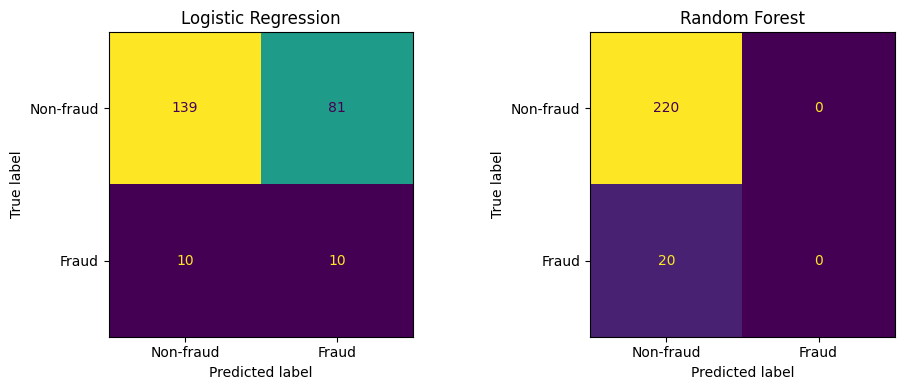

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_pred),
    display_labels=["Non-fraud", "Fraud"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=["Non-fraud", "Fraud"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

## 8. ROC-AUC comparison

ROC-AUC measures ranking ability across classification thresholds. It is useful here because the fraud class is imbalanced and threshold selection is a business decision.

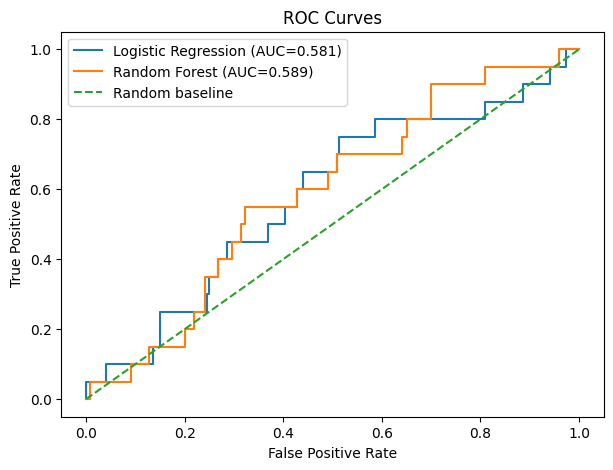

In [14]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC={lr_metrics['ROC-AUC']:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

## 9. Precision–Recall and threshold analysis

A fraud detector does not have to use a 0.50 probability threshold.

Changing the threshold changes the balance between:

- catching more fraudulent transactions (Recall)
- avoiding unnecessary fraud alerts (Precision)

The following analysis evaluates several thresholds on the **untouched test set**. No threshold is presented as a production recommendation because the target is synthetic and the project does not contain real operational fraud costs.

In [15]:
def threshold_table(y_true, probabilities, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []
    for threshold in thresholds:
        pred = (probabilities >= threshold).astype(int)
        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0)
        })
    return pd.DataFrame(rows)

lr_thresholds = threshold_table(y_test, lr_prob)
rf_thresholds = threshold_table(y_test, rf_prob)

print("Logistic Regression threshold analysis")
display(lr_thresholds.round(3))

print("Random Forest threshold analysis")
display(rf_thresholds.round(3))

Logistic Regression threshold analysis


,Threshold,Precision,Recall,F1
0,0.10,0.082,0.95,0.151
1,0.15,0.083,0.90,0.151
2,0.20,0.083,0.85,0.152
3,0.25,0.086,0.80,0.155
4,0.30,0.092,0.80,0.166
5,0.35,0.110,0.80,0.194
6,0.40,0.117,0.75,0.203
7,0.45,0.117,0.65,0.198
8,0.50,0.110,0.50,0.180
9,0.55,0.119,0.40,0.184


Random Forest threshold analysis


,Threshold,Precision,Recall,F1
0,0.10,0.096,0.70,0.169
1,0.15,0.120,0.55,0.196
2,0.20,0.077,0.20,0.111
3,0.25,0.097,0.15,0.118
4,0.30,0.067,0.05,0.057
5,0.35,0.143,0.05,0.074
6,0.40,0.333,0.05,0.087
7,0.45,0.000,0.00,0.000
8,0.50,0.000,0.00,0.000
9,0.55,0.000,0.00,0.000


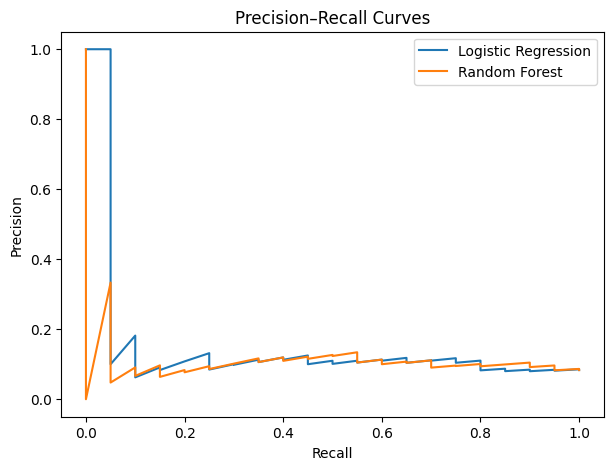

In [16]:
# Precision/Recall curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.show()

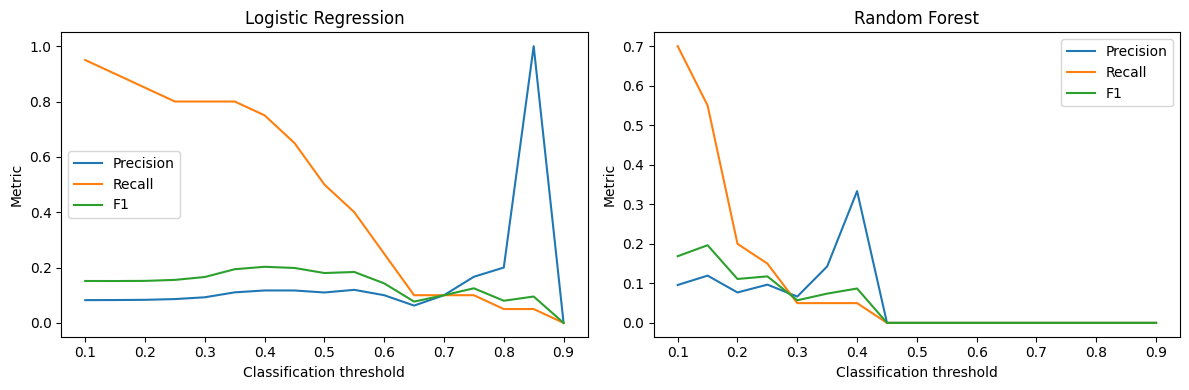

In [17]:
# Threshold trade-off plot for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for table, name, ax in [
    (lr_thresholds, "Logistic Regression", axes[0]),
    (rf_thresholds, "Random Forest", axes[1])
]:
    ax.plot(table["Threshold"], table["Precision"], label="Precision")
    ax.plot(table["Threshold"], table["Recall"], label="Recall")
    ax.plot(table["Threshold"], table["F1"], label="F1")
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel("Metric")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Error analysis and business interpretation

False positives are non-fraud transactions flagged as fraud. False negatives are fraud transactions missed by the model.

For a fraud-screening workflow, a lower threshold generally flags more transactions for review and can increase Recall, but it can also increase false-positive alerts. A higher threshold generally produces fewer alerts but may allow more simulated fraudulent transactions to pass undetected.

Because this project uses a synthetic fraud target and does not provide real financial or operational costs for false positives and false negatives, the analysis does not prescribe a production threshold. Instead, it demonstrates how threshold choice changes the Precision–Recall trade-off.

In [18]:
def error_examples(X_original, y_true, probabilities, threshold=0.50, n=10):
    result = X_original.copy()
    result["ActualFraud"] = y_true.values
    result["FraudProbability"] = probabilities
    result["PredictedFraud"] = (probabilities >= threshold).astype(int)

    result["ErrorType"] = np.select(
        [
            (result["ActualFraud"] == 1) & (result["PredictedFraud"] == 0),
            (result["ActualFraud"] == 0) & (result["PredictedFraud"] == 1)
        ],
        [
            "False Negative",
            "False Positive"
        ],
        default="Correct"
    )

    return result[result["ErrorType"] != "Correct"].sort_values(
        "FraudProbability", ascending=False
    ).head(n)

print("Logistic Regression error examples:")
display(error_examples(X_test.reset_index(drop=True), y_test.reset_index(drop=True), lr_prob))

print("Random Forest error examples:")
display(error_examples(X_test.reset_index(drop=True), y_test.reset_index(drop=True), rf_prob))

Logistic Regression error examples:


,Product,Quantity,UnitPrice,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,UsedCoupon,OrderMonth,OrderYear,ActualFraud,FraudProbability,PredictedFraud,ErrorType
180,Printer,4,626.01,Online,8,SAVE10,Email,2504.04,1,5,2025,0,0.835885,1,False Positive
166,Monitor,4,451.97,Online,7,WINTER15,Email,1807.88,1,1,2025,0,0.816896,1,False Positive
214,Printer,4,611.26,Cash,5,SAVE10,Referral,2445.04,1,2,2023,0,0.814671,1,False Positive
52,Phone,5,634.00,Gift Card,8,No Coupon,Email,3170.00,0,6,2024,0,0.801201,1,False Positive
38,Monitor,2,662.53,Online,5,No Coupon,Facebook,1325.06,0,3,2024,0,0.796506,1,False Positive
213,Laptop,1,634.40,Cash,6,SAVE10,Email,634.40,1,4,2023,0,0.795353,1,False Positive
207,Monitor,3,659.57,Credit Card,6,SAVE10,Email,1978.71,1,3,2023,0,0.789029,1,False Positive
70,Phone,1,424.40,Online,6,WINTER15,Referral,424.40,1,2,2023,0,0.787250,1,False Positive
170,Laptop,1,634.94,Online,5,WINTER15,Instagram,634.94,1,3,2023,0,0.765235,1,False Positive
151,Phone,4,488.78,Online,5,FREESHIP,Google,1955.12,1,5,2024,0,0.755192,1,False Positive


Random Forest error examples:


,Product,Quantity,UnitPrice,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,UsedCoupon,OrderMonth,OrderYear,ActualFraud,FraudProbability,PredictedFraud,ErrorType
184,Monitor,2,500.29,Online,7,WINTER15,Google,1000.5800,1,9,2024,1,0.423057,0,False Negative
86,Desk,3,568.02,Online,3,FREESHIP,Instagram,1704.0600,1,9,2024,1,0.265507,0,False Negative
146,Printer,4,637.79,Gift Card,9,FREESHIP,Google,2551.1600,1,4,2025,1,0.251912,0,False Negative
53,Chair,4,534.48,Online,9,WINTER15,Instagram,2137.9200,1,12,2024,1,0.217989,0,False Negative
232,Phone,4,162.71,Cash,7,FREESHIP,Email,650.8400,1,4,2024,1,0.199491,0,False Negative
68,Chair,4,655.18,Online,5,No Coupon,Facebook,2620.7200,0,11,2023,1,0.196181,0,False Negative
231,Printer,4,567.57,Debit Card,9,WINTER15,Google,2270.2800,1,6,2024,1,0.194609,0,False Negative
154,Printer,5,260.93,Online,9,SAVE10,Email,1304.6500,1,6,2023,1,0.189795,0,False Negative
75,Chair,5,676.98,Cash,5,No Coupon,Facebook,3330.4075,0,11,2023,1,0.174620,0,False Negative
145,Printer,4,634.05,Cash,6,SAVE10,Google,2536.2000,1,5,2025,1,0.165677,0,False Negative


## 11. Random Forest feature importance

Feature importance is included as a diagnostic tool. It should be interpreted in the context of the synthetic label-generation process: strong importance does not establish that the feature is a real-world fraud cause.

,Feature,Importance
3,num__TotalPrice,0.078212
1,num__UnitPrice,0.074797
15,cat__PaymentMethod_Credit Card,0.064638
0,num__Quantity,0.059586
2,num__ItemsInCart,0.057928
18,cat__PaymentMethod_Online,0.056310
5,num__OrderMonth,0.053391
25,cat__ReferralSource_Google,0.043779
6,num__OrderYear,0.042635
19,cat__CouponCode_FREESHIP,0.041688


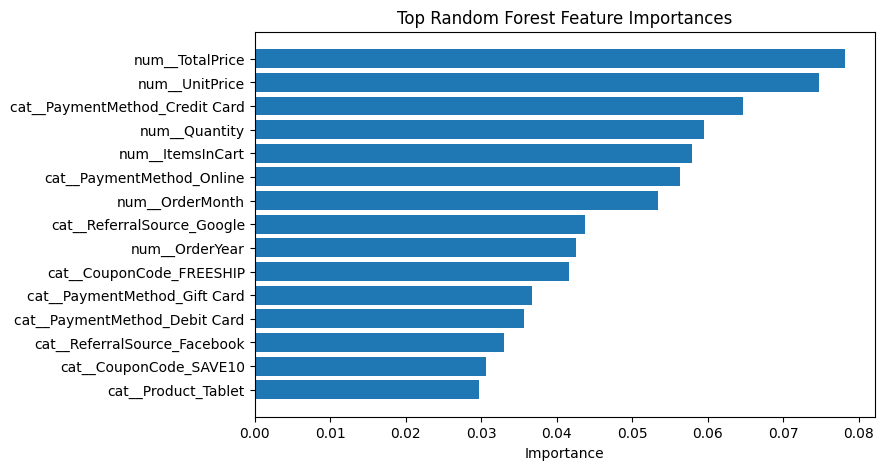

In [19]:
# Recover transformed feature names and display Random Forest importances
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.show()

## 12. Final interpretation

### What this project demonstrates

1. A class-imbalanced supervised-learning problem can be constructed from the cleaned Project 1 data using a documented synthetic fraud target.
2. SMOTE can be applied safely **inside the training pipeline after the stratified train/test split**, leaving the test set untouched.
3. Logistic Regression and Random Forest provide two different classification approaches.
4. Precision, Recall, F1 and ROC-AUC are more informative than relying on Accuracy alone for an imbalanced fraud task.
5. Threshold selection changes the Precision–Recall trade-off and therefore changes the number of transactions that would be flagged for review.

### Interpreting the model results

ROC-AUC should not be interpreted as equivalent to performance at the default 0.50 threshold. The threshold analysis is therefore an important companion to the model-comparison table, particularly when a model produces few or no positive predictions at 0.50.

### Critical limitation

The target is synthetic. Therefore:

- model performance is not evidence of real fraud-detection capability;
- feature importance is not evidence of causal fraud drivers;
- threshold analysis is educational rather than production policy;
- conclusions describe recovery of the simulated labeling mechanism, not real-world fraud behavior.

### Reproducibility

The synthetic dataset is versioned in the project GitHub repository and is loaded directly from its raw CSV endpoint. The modeling pipeline uses a fixed random seed where applicable.

In [20]:
# Final reproducibility and dataset summary
print("PROJECT 2 COMPLETE")
print("=" * 60)
print(f"Dataset page: {DATASET_PAGE_URL}")
print(f"Rows: {len(df):,}")
print(f"Fraud: {int(y.sum()):,} ({y.mean()*100:.2f}%)")
print(f"Non-fraud: {int((y == 0).sum()):,} ({(1-y.mean())*100:.2f}%)")
print(f"Random seed: {RANDOM_STATE}")

print("\nModel comparison:")
display(results.round(4))

PROJECT 2 COMPLETE
Dataset page: https://github.com/rsf-rawnak/DecodeLabs-DS-Internship/blob/main/Initial-dataset/Synthetic-dataset/project2_fraud_dataset.csv
Rows: 1,200
Fraud: 102 (8.50%)
Non-fraud: 1,098 (91.50%)
Random seed: 20260925

Model comparison:


,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.1099,0.5,0.1802,0.5807
Random Forest,0.0000,0.0,0.0000,0.5893


## 13. Submission checklist

- [x] Project 1 cleaned dataset is the upstream foundation.
- [x] Synthetic `IsFraud` target is explicitly disclosed as educational.
- [x] Dataset source is provided via the project GitHub repository.
- [x] Identifiers and other leakage-prone fields are excluded from model features.
- [x] `OrderStatus` is excluded and is not used as the fraud label.
- [x] Stratified 80/20 train/test split is performed before SMOTE.
- [x] SMOTE is applied only within the training pipeline.
- [x] Logistic Regression is evaluated.
- [x] Random Forest is evaluated.
- [x] Precision, Recall, F1-score and ROC-AUC are reported.
- [x] Threshold analysis is performed on the untouched test set.
- [x] Error analysis and feature-importance diagnostics are included.
- [x] Business/operational interpretation is framed without claiming production effectiveness.
- [x] The synthetic-target limitation is stated clearly.

> **Final note:** This notebook starts from the already-created synthetic dataset by design. The dataset-generation step is documented separately in the project methodology, while this notebook contains the supervised-learning and evaluation pipeline.